# Imports

In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{bm}", # Recomendado para negritas matemáticas
})

In [3]:
import os
import sys

In [4]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [5]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [7]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [8]:

dir = "./../../data/uvtable/"
data_file = dir + "uvtable_SimulatedBlob.txt"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

# Load data
file = np.loadtxt(data_file, unpack=True)
u, v, Re, Im, Weights = file
Vis = Re + 1j*Im
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

## frank2d for differents N

In [9]:
N = [50, 100, 300, 500, 1000, 3000, 6000]

In [10]:
Rmax = 2* rout

In [11]:
frank2d_objects = []

### Load objects

In [12]:
import pickle
# load objects
frank2d_objects = []
import pickle
dir_ = "./../../data/exp/N/"
for i in range(len(N)):
    with open(dir_ + "SimulatedBlob_N_"+str(N[i])+ ".pkl", "rb") as file:
        frank2d = pickle.load(file)
        frank2d_objects.append(frank2d)

### Run 


In [11]:
times = []

In [12]:
best_N50 = {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}

In [13]:
for i in range(len(N)):
    start = time.time()
    frank2d = Frank2D(N[i], Rmax)
    frank2d.fit(data = uvtable, kernel_params = best_N50, rtol = 1e-8)

    end = time.time()
    total_time = end - start
    times.append(total_time)
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D withN={N[-1]} took {end - start} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")
    frank2d_objects.append(frank2d)


===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.00  min |  0.10 seconds
        +  Building system = 0.00  min |  0.10 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 74/50000 [00:04<45:29, 18.29 iterations/s] 


            +  BiCGStab = 0.07  min |  4.05 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 10.08216141202927,
 'iterations': 74,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-08}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.00  min |  0.02 seconds
--> times building full visibility model = 0.00  min |  0.02 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D withN=6000 took 5.228574752807617 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.01  min |  0.67 seconds
        +  Building system = 0.01  min |  0.68 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 74/50000 [00:05<1:04:04, 12.99 iterations/s]


            +  BiCGStab = 0.10  min |  5.70 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 10.082246265201162,
 'iterations': 74,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-08}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.00  min |  0.14 seconds
--> times building full visibility model = 0.00  min |  0.15 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D withN=6000 took 8.594862937927246 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.57 seconds
        +  Building system = 0.03  min |  1.59 seconds
===>  Solving linear system...


...

            +  BiCGStab = 0.21  min |  12.64 seconds
{'CGM_converged': True,
 'Fit_correctly': False,
 'convergence_by': 'norm of s',
 'final_tol': 10.082246852331034,
 'iterations': 71,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-08}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.78  min |  47.01 seconds
--> times building full visibility model = 0.78  min |  47.05 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D withN=6000 took 66.7047655582428 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  2.10 seconds
        +  Building system = 0.04  min |  2.12 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 71/50000 [00:11<2:14:45,  6.18 iterations/s]


            +  BiCGStab = 0.19  min |  11.57 seconds
{'CGM_converged': True,
 'Fit_correctly': False,
 'convergence_by': 'norm of s',
 'final_tol': 10.082246852331034,
 'iterations': 71,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-08}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 5.26  min |  315.60 seconds
--> times building full visibility model = 5.27  min |  316.04 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D withN=6000 took 345.6239001750946 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.56 seconds
        +  Building system = 0.03  min |  1.58 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 71/50000 [00:05<1:07:06, 12.40 iterations/s]


            +  BiCGStab = 0.10  min |  5.75 seconds
{'CGM_converged': True,
 'Fit_correctly': False,
 'convergence_by': 'norm of s',
 'final_tol': 10.082246852331034,
 'iterations': 71,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-08}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 20.51  min |  1230.79 seconds
--> times building full visibility model = 20.54  min |  1232.53 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D withN=6000 took 1291.449517250061 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


### Complexity plot 

In [43]:
times = [5.228574752807617, 8.594862937927246, 17.404186010360718, 19.21261763572693,66.7047655582428, 345.6239001750946, 1291.449517250061]
opt_time = 157.7723855495453 #sec

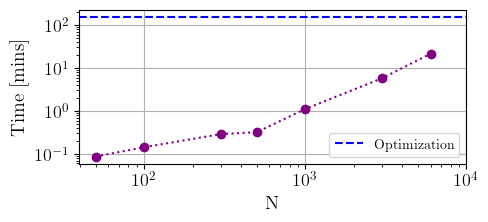

In [61]:
plt.figure(figsize=(5,2))
plt.plot(N, np.array(times)/60, marker='o', ls=':', color = 'purple')
plt.axhline(y= opt_time, color='blue', linestyle='--', label=r'Optimization')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('N', fontsize=14)
plt.xlim(0, 1e4)
plt.legend(loc='best', fontsize=10)
plt.tick_params(axis='both', which='major', labelsize=13)
plt.ylabel('Time [mins]', fontsize=14)
plt.grid()
plt.show()


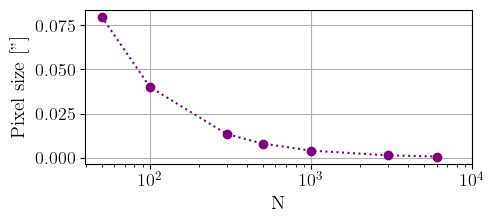

In [56]:
plt.figure(figsize=(5,2))
cellsizes = 2*np.array([frank2d_objects[i].Rmax /frank2d_objects[i].N for i in range(len(N))])
plt.plot(N, cellsizes, marker='o', ls=':', color = 'purple')
plt.xscale('log')
#plt.yscale('log')
plt.xlabel('N', fontsize=14)
plt.xlim(0, 1e4)
plt.tick_params(axis='both', which='major', labelsize=13)
plt.ylabel('Pixel size ["]', fontsize=14)
plt.grid()
#plt.title(r'Frankenstein2D for a $N^{2}$ pixels image', fontsize=10)

In [29]:
Qmax = max(np.hypot(u,v))
Qmin = (np.unique(np.hypot(u,v))[1:]).min()

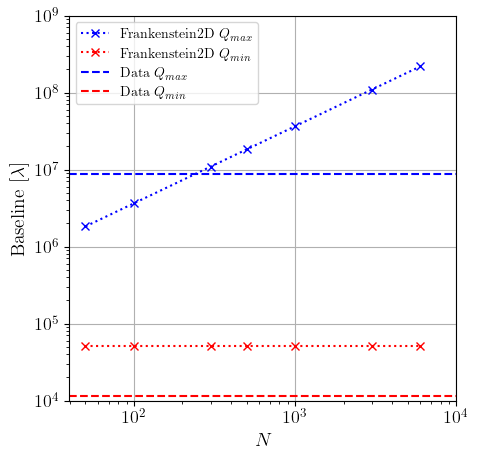

In [60]:
q_max = []
for i in range(len(N)):
    q_max.append(np.max(frank2d_objects[i].FT.q))

q_min = []
for i in range(len(N)):
    q_min.append(np.min((np.unique(frank2d_objects[i].FT.q)[1:])))


plt.figure(figsize=(5,5))
plt.plot(N, np.array(q_max), marker='x', ls=':', color = 'blue', label='Frankenstein2D $Q_{max}$')
plt.plot(N, np.array(q_min), marker='x', ls=':', color = 'red', label='Frankenstein2D $Q_{min}$')
plt.axhline(y= Qmax, color='blue', linestyle='--', label=r'Data $Q_{max}$')
plt.axhline(y= Qmin, color='r', linestyle='--', label=r'Data $Q_{min}$')
plt.xlabel( r'$N$', fontsize=14)
plt.ylabel(r'Baseline [$\lambda$]', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=13)
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e4, 1e9)
plt.xlim(0, 1e4)
plt.legend(loc='best', fontsize=10)
plt.grid()
plt.show()

## Analize differents results

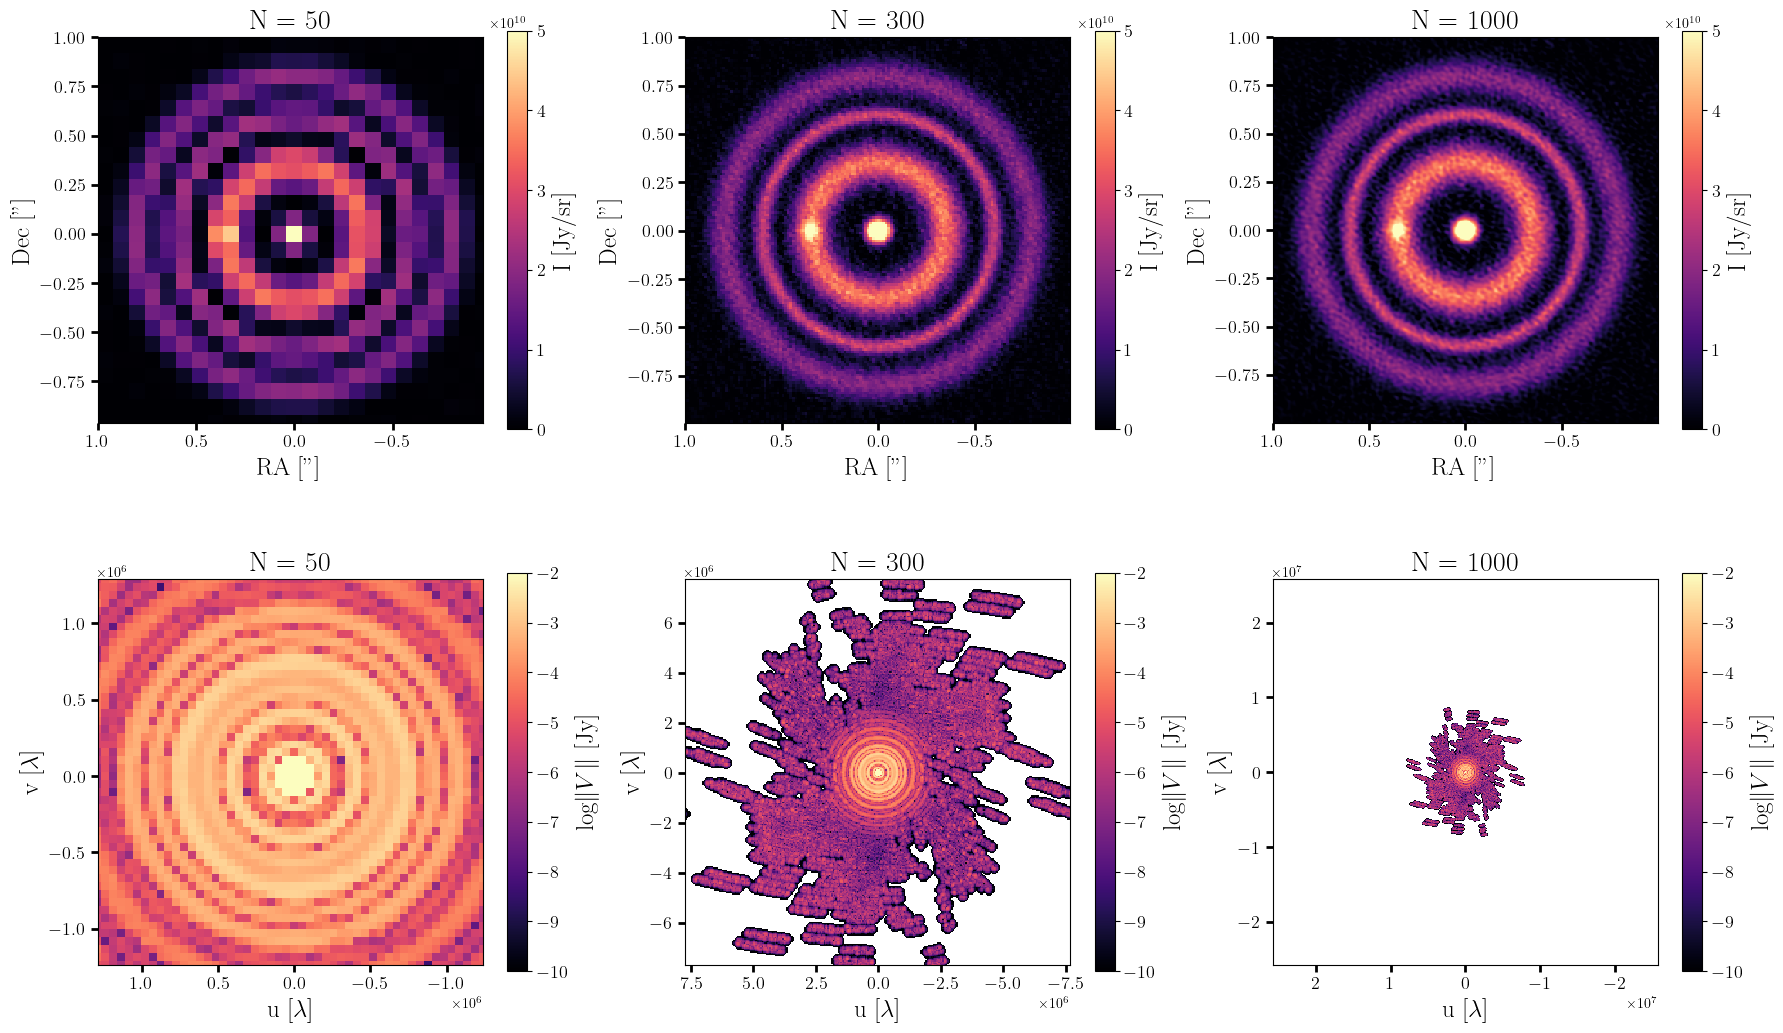

In [14]:
import matplotlib.pyplot as plt

indices_a_plotear = [0, 2, 4]

frank2d_seleccionados = [frank2d_objects[i] for i in indices_a_plotear]
N_seleccionados = [N[i] for i in indices_a_plotear]

num_cols = len(N_seleccionados)

fig, axes = plt.subplots(nrows=2, ncols=num_cols, figsize=(6 * num_cols, 11))

if num_cols == 1:
    axes = axes.reshape(2, 1)

for i in range(num_cols):
    Plot_ = Plot(frank2d_seleccionados[i], geom) 
    N_valor = N_seleccionados[i] 

    Plot_.intensity(ax=axes[0, i], vmax=5e10, gamma=1, zoom=2,
                     title=r' N = ' + str(N_valor), label_size=18)
    
    Plot_.visibility(ax=axes[1, i], fig_size=6,
                      title=r' N = ' + str(N_valor), label_size=18)

plt.tight_layout()
plt.show()

In [19]:
for i in range(len(N)):
    frank2d_objects[i].time = times[i]

In [20]:
for i in range(len(N)):
    print(f"N={N[i]} took {frank2d_objects[i].time/60} minutes")

N=50 took 0.08714291254679361 minutes
N=100 took 0.14324771563212077 minutes
N=300 took 0.2900697668393453 minutes
N=500 took 0.32021029392878214 minutes
N=1000 took 1.11174609263738 minutes
N=3000 took 5.760398336251577 minutes
N=6000 took 21.52415862083435 minutes


In [21]:
#save object
import pickle

dir_ = "./../../data/exp/N/"
for i in range(len(N)):
    with open(dir_ + "SimulatedBlob_"+"N_"+str(N[i])+ ".pkl", "wb") as file:
        pickle.dump(frank2d_objects[i], file)